# Tier4 PECNet YahooQuery Research - Example2 Method

Bu notebook `pecnetframework/example2.py` metodolojisini YahooQuery verisine uygular:

- Veri doğrudan `yahooquery` ile çekilir.
- Target (`y`) önce preprocess edilir.
- `FEATURE_COLUMNS` içindeki tüm featurelar ayrı ayrı preprocess edilir.
- Feature selection yapılmaz.
- PECNet `target_history + tüm feature networkleri + error network + final network` şeklinde kurulur.
- Parametreler ve feature kolonları mevcut araştırma notebookundaki değerlerle aynıdır.


## 1. Imports

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from yahooquery import Ticker

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
PECNETFRAMEWORK_PATH = PROJECT_ROOT / "pecnetframework"
if str(PECNETFRAMEWORK_PATH) not in sys.path:
    sys.path.insert(0, str(PECNETFRAMEWORK_PATH))

from pecnet.network import PecnetBuilder
from pecnet.preprocessing.DataPreprocessor import DataPreprocessor
from pecnet.utils import Utility

pd.options.display.max_columns = 120
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Config

In [2]:
SYMBOLS = ["TUPRS.IS"]
PERIOD = "5y"
INTERVAL = "1d"

FEATURE_COLUMNS = [
    "prev_open",
    "prev_high",
    "prev_low",
    "prev_volume",
    "calendar_gap_days",
    "month_sin_1",
    "month_cos_1",
    "month_sin_2",
    "month_cos_2",
    "day_sin_1",
    "day_cos_1",
    "day_sin_2",
    "day_cos_2",
    "day_of_year_sin_1",
    "day_of_year_cos_1",
    "day_of_year_sin_2",
    "day_of_year_cos_2",
]

PREPROCESS_PARAMS = {
    "sampling_periods": [1, 2, 4],
    "sampling_statistics": ["mean", 'std'],
    "sequence_size": 4,
    "error_sequence_size": 8,
    "wavelet_type": "haar",
    "test_ratio": 0.1,
    'scale_factor': 1.3,
    'target_normalization_type': 'window_mean',
    'conjoincy': False,
}

HYPERPARAMS = {
    "learning_rate": 0.001,
    "epoch_size": 500,
    "batch_size": 96,
    "hidden_units_sizes": [32, 64, 32, 16],
}

## 3. YahooQuery Data Pull

In [3]:
def _datetime_column(frame: pd.DataFrame) -> str | None:
    for column in ["date", "datetime", "level_1", "index"]:
        if column not in frame.columns:
            continue
        converted = pd.to_datetime(frame[column], errors="coerce", utc=True)
        if converted.notna().mean() >= 0.8:
            return column
    return None


def normalize_yahooquery_history(raw: pd.DataFrame, symbol: str) -> pd.DataFrame:
    if isinstance(raw, dict):
        raise RuntimeError(f"YahooQuery returned an error payload for {symbol}: {raw}")
    if raw is None or raw.empty:
        raise RuntimeError(f"YahooQuery returned no rows for {symbol}.")

    frame = raw.reset_index().copy()
    frame.columns = [str(column).lower() for column in frame.columns]

    date_column = _datetime_column(frame)
    if date_column is None:
        raise ValueError(f"Could not find a datetime column for {symbol}. Columns={list(frame.columns)}")
    if date_column != "date":
        frame = frame.rename(columns={date_column: "date"})

    if "symbol" not in frame.columns:
        frame["symbol"] = symbol
    else:
        frame["symbol"] = frame["symbol"].fillna(symbol).astype(str)

    required = ["symbol", "date", "open", "high", "low", "close", "volume"]
    missing = sorted(set(required).difference(frame.columns))
    if missing:
        raise ValueError(f"YahooQuery data for {symbol} is missing columns: {missing}. Columns={list(frame.columns)}")

    frame = frame[required].copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce", utc=True).dt.tz_convert(None)
    for column in ["open", "high", "low", "close", "volume"]:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.dropna(subset=required).sort_values(["symbol", "date"])
    return frame.reset_index(drop=True)


def fetch_yahooquery_prices(
    symbols: list[str],
    *,
    period: str,
    interval: str,
) -> pd.DataFrame:
    frames = []
    for symbol in symbols:
        print(f"Fetching {symbol}...")
        raw = Ticker(symbol, asynchronous=False).history(period=period, interval=interval)
        frames.append(normalize_yahooquery_history(raw, symbol))
    if not frames:
        raise RuntimeError("No symbols were requested.")
    return pd.concat(frames, ignore_index=True).sort_values(["symbol", "date"]).reset_index(drop=True)

In [4]:
prices = fetch_yahooquery_prices(SYMBOLS, period=PERIOD, interval=INTERVAL)
print(f"rows={len(prices):,} symbols={prices['symbol'].nunique()}")
display(prices.groupby("symbol").agg(rows=("date", "size"), start=("date", "min"), end=("date", "max")))
display(prices.tail())

Fetching TUPRS.IS...
rows=1,251 symbols=1


,rows,start,end
symbol,,,
TUPRS.IS,1251,2021-07-19,2026-07-17


,symbol,date,open,high,low,close,volume
1246,TUPRS.IS,2026-07-10,264.25,270.00,262.25,267.00,25522430.0
1247,TUPRS.IS,2026-07-13,271.50,273.00,266.50,268.25,24414654.0
1248,TUPRS.IS,2026-07-14,270.00,273.50,267.75,270.75,24519320.0
1249,TUPRS.IS,2026-07-16,271.25,286.75,271.25,286.25,29371641.0
1250,TUPRS.IS,2026-07-17,287.00,288.50,283.25,287.75,13242066.0


## 4. Feature Engineering

In [5]:
def fourier_terms(date: pd.Series, *, period: float, harmonics: tuple[int, ...], prefix: str) -> pd.DataFrame:
    values = date.astype(float)
    data = {}
    for harmonic in harmonics:
        angle = 2.0 * np.pi * harmonic * values / period
        data[f"{prefix}_sin_{harmonic}"] = np.sin(angle)
        data[f"{prefix}_cos_{harmonic}"] = np.cos(angle)
    return pd.DataFrame(data, index=date.index)

In [6]:
def fill_business_days_for_symbol(symbol_frame: pd.DataFrame) -> pd.DataFrame:
    print(f"Filling business days for {symbol_frame}...")
    symbol = str(symbol_frame.name)
    print(f"Filling business days for {symbol}...")
    symbol_frame = symbol_frame.sort_values("date").drop_duplicates("date", keep="last")
    grid = pd.DataFrame({"date": pd.bdate_range(symbol_frame["date"].min(), symbol_frame["date"].max())})
    filled = grid.merge(symbol_frame, on="date", how="left")
    filled["symbol"] = symbol
    filled["synthetic_row"] = filled["close"].isna()

    price_columns = ["open", "high", "low", "close", "volume"]
    filled[price_columns] = filled[price_columns].ffill().bfill()

    actual_segment = (~filled["synthetic_row"]).astype(int).cumsum()
    synthetic_run = filled.groupby(actual_segment).cumcount()
    previous_run = synthetic_run.shift(1).fillna(0).astype(int)
    filled["calendar_gap_days"] = np.where(
        filled["synthetic_row"],
        synthetic_run,
        np.where(previous_run > 0, previous_run, 0),
    ).astype(float)
    return filled

In [7]:
prices_copy = prices.copy()
gruplanmis = prices_copy.groupby("symbol", group_keys=False)

for isim, grup in gruplanmis:
    print(f"--- Grup: {isim} ---")
    display(grup) # Konsolda çalışıyorsan 'print(grup)' kullanabilirsin

--- Grup: TUPRS.IS ---


,symbol,date,open,high,low,close,volume
0,TUPRS.IS,2021-07-19,13.492857,13.492857,13.378571,13.400000,4664205.0
1,TUPRS.IS,2021-07-26,13.421428,13.457142,13.121428,13.150000,19031124.0
2,TUPRS.IS,2021-07-27,13.121428,13.214285,13.000000,13.192857,19472152.0
3,TUPRS.IS,2021-07-28,13.185714,13.285714,13.107142,13.128571,18230023.0
4,TUPRS.IS,2021-07-29,13.221428,13.457142,13.221428,13.442857,23116380.0
...,...,...,...,...,...,...,...
1246,TUPRS.IS,2026-07-10,264.250000,270.000000,262.250000,267.000000,25522430.0
1247,TUPRS.IS,2026-07-13,271.500000,273.000000,266.500000,268.250000,24414654.0
1248,TUPRS.IS,2026-07-14,270.000000,273.500000,267.750000,270.750000,24519320.0
1249,TUPRS.IS,2026-07-16,271.250000,286.750000,271.250000,286.250000,29371641.0


In [8]:
def build_tier4_features(prices: pd.DataFrame) -> pd.DataFrame:
    filled = (
        prices.groupby("symbol", group_keys=False)
        .apply(fill_business_days_for_symbol)
        .reset_index(drop=True)
        .sort_values(["symbol", "date"])
    )
    print(f"rows={len(filled):,} symbols={filled['symbol'].nunique()}")
    display(filled)
    for column in ["open", "high", "low", "volume"]:
        filled[f"prev_{column}"] = filled.groupby("symbol")[column].shift(1)

    month_terms = fourier_terms(filled["date"].dt.month, period=12.0, harmonics=(1, 2), prefix="month")
    day_terms = fourier_terms(filled["date"].dt.day, period=31.0, harmonics=(1, 2), prefix="day")
    doy_terms = fourier_terms(filled["date"].dt.dayofyear, period=366.0, harmonics=(1, 2), prefix="day_of_year")
    enriched = pd.concat([filled, month_terms, day_terms, doy_terms], axis=1)
    print(f"rows={len(enriched):,} symbols={enriched['symbol'].nunique()}")
    model_frame = enriched.rename(columns={"symbol": "unique_id", "date": "ds", "close": "y"})
    model_frame = model_frame[["unique_id", "ds", "y", *FEATURE_COLUMNS]].copy()
    model_frame = model_frame.dropna(subset=["unique_id", "ds", "y", *FEATURE_COLUMNS])
    return model_frame.sort_values(["unique_id", "ds"]).reset_index(drop=True)

In [9]:
model_frame = build_tier4_features(prices)
print(f"model_rows={len(model_frame):,}")
display(model_frame.groupby("unique_id").agg(rows=("ds", "size"), start=("ds", "min"), end=("ds", "max")))
display(model_frame.tail())

Filling business days for            date        open        high         low       close      volume
0    2021-07-19   13.492857   13.492857   13.378571   13.400000   4664205.0
1    2021-07-26   13.421428   13.457142   13.121428   13.150000  19031124.0
2    2021-07-27   13.121428   13.214285   13.000000   13.192857  19472152.0
3    2021-07-28   13.185714   13.285714   13.107142   13.128571  18230023.0
4    2021-07-29   13.221428   13.457142   13.221428   13.442857  23116380.0
...         ...         ...         ...         ...         ...         ...
1246 2026-07-10  264.250000  270.000000  262.250000  267.000000  25522430.0
1247 2026-07-13  271.500000  273.000000  266.500000  268.250000  24414654.0
1248 2026-07-14  270.000000  273.500000  267.750000  270.750000  24519320.0
1249 2026-07-16  271.250000  286.750000  271.250000  286.250000  29371641.0
1250 2026-07-17  287.000000  288.500000  283.250000  287.750000  13242066.0

[1251 rows x 6 columns]...
Filling business days for TUPRS.IS

,date,open,high,low,close,volume,symbol,synthetic_row,calendar_gap_days
0,2021-07-19,13.492857,13.492857,13.378571,13.40,4664205.0,TUPRS.IS,False,0.0
1,2021-07-20,13.492857,13.492857,13.378571,13.40,4664205.0,TUPRS.IS,True,1.0
2,2021-07-21,13.492857,13.492857,13.378571,13.40,4664205.0,TUPRS.IS,True,2.0
3,2021-07-22,13.492857,13.492857,13.378571,13.40,4664205.0,TUPRS.IS,True,3.0
4,2021-07-23,13.492857,13.492857,13.378571,13.40,4664205.0,TUPRS.IS,True,4.0
...,...,...,...,...,...,...,...,...,...
1300,2026-07-13,271.500000,273.000000,266.500000,268.25,24414654.0,TUPRS.IS,False,0.0
1301,2026-07-14,270.000000,273.500000,267.750000,270.75,24519320.0,TUPRS.IS,False,0.0
1302,2026-07-15,270.000000,273.500000,267.750000,270.75,24519320.0,TUPRS.IS,True,1.0
1303,2026-07-16,271.250000,286.750000,271.250000,286.25,29371641.0,TUPRS.IS,False,1.0


rows=1,305 symbols=1
model_rows=1,304


,rows,start,end
unique_id,,,
TUPRS.IS,1304,2021-07-20,2026-07-17


,unique_id,ds,y,prev_open,prev_high,prev_low,prev_volume,calendar_gap_days,month_sin_1,month_cos_1,month_sin_2,month_cos_2,day_sin_1,day_cos_1,day_sin_2,day_cos_2,day_of_year_sin_1,day_of_year_cos_1,day_of_year_sin_2,day_of_year_cos_2
1299,TUPRS.IS,2026-07-13,268.25,264.25,270.00,262.25,25522430.0,0.0,-0.5,-0.866025,0.866025,0.5,0.485302,-0.874347,-0.848644,0.528964,-0.187719,-0.982223,0.368763,0.929523
1300,TUPRS.IS,2026-07-14,270.75,271.50,273.00,266.50,24414654.0,0.0,-0.5,-0.866025,0.866025,0.5,0.299363,-0.954139,-0.571268,0.820763,-0.204552,-0.978856,0.400454,0.916317
1301,TUPRS.IS,2026-07-15,270.75,270.00,273.50,267.75,24519320.0,1.0,-0.5,-0.866025,0.866025,0.5,0.101168,-0.994869,-0.201299,0.979530,-0.221325,-0.975200,0.431673,0.902030
1302,TUPRS.IS,2026-07-16,286.25,270.00,273.50,267.75,24519320.0,1.0,-0.5,-0.866025,0.866025,0.5,-0.101168,-0.994869,0.201299,0.979530,-0.238033,-0.971257,0.462383,0.886680
1303,TUPRS.IS,2026-07-17,287.75,271.25,286.75,271.25,29371641.0,0.0,-0.5,-0.866025,0.866025,0.5,-0.299363,-0.954139,0.571268,0.820763,-0.254671,-0.967028,0.492548,0.870285


## 5. PECNet Example2 Helpers


In [10]:
def preprocess_ticker(
    *,
    ticker_df: pd.DataFrame,
    ticker: str,
    feature_columns: list[str],
    preprocess_params: dict[str, Any],
) -> dict[str, Any]:
    dp = DataPreprocessor()
    dp.reset()
    ticker_df = ticker_df.sort_values("ds").copy()
    params = {**preprocess_params}
    test_ratio = float(params.get("test_ratio", 0.1))
    if not 0 < test_ratio < 1:
        raise ValueError(f"PECNet test_ratio must be between 0 and 1, got {test_ratio}.")
    params["test_ratio"] = test_ratio

    target_series = ticker_df["y"].to_numpy(dtype=float)
    X_train_target, X_test_target, y_train, y_test = dp.preprocess(data=target_series, **params)

    feature_X_trains = []
    feature_X_tests = []
    available_features = [column for column in feature_columns if column in ticker_df.columns]
    for column in available_features:
        X_train_feature, X_test_feature, _, _ = dp.preprocess(
            data=ticker_df[column].to_numpy(dtype=float),
            **params,
        )
        feature_X_trains.append(X_train_feature)
        feature_X_tests.append(X_test_feature)

    return {
        "ticker": ticker,
        "dates": ticker_df["ds"].reset_index(drop=True),
        "X_train_target": X_train_target,
        "X_test_target": X_test_target,
        "y_train": y_train,
        "y_test": y_test,
        "feature_X_trains": feature_X_trains,
        "feature_X_tests": feature_X_tests,
        "feature_names": available_features,
        "preprocess_params": params,
    }


In [11]:
def candidate_variable_inputs(ticker_data: dict[str, Any]) -> tuple[list[str], list[np.ndarray], list[np.ndarray]]:
    return (
        ["target_history", *ticker_data["feature_names"]],
        [ticker_data["X_train_target"], *ticker_data["feature_X_trains"]],
        [ticker_data["X_test_target"], *ticker_data["feature_X_tests"]],
    )


def variable_row(
    *,
    ticker: str,
    order: int,
    feature_index: int,
    feature_name: str,
    network_role: str,
) -> dict[str, Any]:
    return {
        "ticker": ticker,
        "tier": "tier4",
        "strategy": "example2_all_features_no_selection",
        "network_order": order,
        "feature_index": feature_index,
        "feature_name": feature_name,
        "network_role": network_role,
    }


In [12]:
def build_example2_pecnet_variables(
    *,
    builder,
    ticker_data: dict[str, Any],
) -> tuple[Any, list[np.ndarray], pd.DataFrame]:
    candidate_names, candidate_X_train, candidate_X_test = candidate_variable_inputs(ticker_data)
    print(
        f"Building example2-style tier4 PECNet for {ticker_data['ticker']} "
        f"with target + {len(candidate_names) - 1} feature networks..."
    )

    rows = []
    builder.add_variable_network(ticker_data["X_train_target"], ticker_data["y_train"])
    rows.append(
        variable_row(
            ticker=ticker_data["ticker"],
            order=1,
            feature_index=0,
            feature_name="target_history",
            network_role="primary_target_network",
        )
    )

    for feature_index, (feature_name, X_train_feature) in enumerate(
        zip(candidate_names[1:], candidate_X_train[1:], strict=False),
        start=1,
    ):
        builder.add_variable_network(X_train_feature)
        rows.append(
            variable_row(
                ticker=ticker_data["ticker"],
                order=len(rows) + 1,
                feature_index=feature_index,
                feature_name=feature_name,
                network_role="supportive_feature_network",
            )
        )
        print(f"Added feature network: {feature_name}")

    selected_X_test = candidate_X_test
    return builder, selected_X_test, pd.DataFrame(rows)


In [13]:
def regression_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(actual, predicted)),
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mape": float(mean_absolute_percentage_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)) if len(actual) > 1 else np.nan,
    }


def directional_metrics(joined: pd.DataFrame, full_df: pd.DataFrame) -> dict[str, float]:
    previous_close = (
        full_df[["unique_id", "ds", "y"]]
        .sort_values(["unique_id", "ds"])
        .assign(previous_y=lambda frame: frame.groupby("unique_id")["y"].shift(1))
    )
    eval_frame = joined.merge(previous_close[["unique_id", "ds", "previous_y"]], on=["unique_id", "ds"], how="left")
    actual_up = eval_frame["y"] > eval_frame["previous_y"]
    predicted_up = eval_frame["PECNet"] > eval_frame["previous_y"]
    valid = eval_frame["previous_y"].notna()
    if not valid.any():
        return {"long_accuracy": np.nan, "long_precision": np.nan, "long_recall": np.nan, "long_signal_rate": np.nan}
    tp = int((predicted_up & actual_up & valid).sum())
    fp = int((predicted_up & ~actual_up & valid).sum())
    fn = int((~predicted_up & actual_up & valid).sum())
    return {
        "long_accuracy": float((predicted_up[valid] == actual_up[valid]).mean()),
        "long_precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "long_recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
        "long_signal_rate": float(predicted_up[valid].mean()),
    }


## 6. Train Example2-Style Tier4 PECNet


In [14]:
def to_numpy_vector(values: Any) -> np.ndarray:
    return values.detach().cpu().numpy().reshape(-1) if hasattr(values, "detach") else np.asarray(values).reshape(-1)


def train_one_ticker_tier4(
    *,
    ticker: str,
    full_df: pd.DataFrame,
) -> tuple[Any, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    Utility.set_seed(HYPERPARAMS.get("seed", 42))
    Utility.set_hyperparameters(
        learning_rate=HYPERPARAMS["learning_rate"],
        epoch_size=HYPERPARAMS["epoch_size"],
        batch_size=HYPERPARAMS["batch_size"],
        hidden_units_sizes=HYPERPARAMS["hidden_units_sizes"],
    )

    full_df = full_df.sort_values("ds").copy()
    ticker_data = preprocess_ticker(
        ticker_df=full_df,
        ticker=ticker,
        feature_columns=FEATURE_COLUMNS,
        preprocess_params=PREPROCESS_PARAMS,
    )
    builder, selected_X_test, variable_plan = build_example2_pecnet_variables(
        builder=PecnetBuilder(),
        ticker_data=ticker_data,
    )
    display(variable_plan)

    pecnet = builder.add_error_network().add_final_network().build()
    raw_predictions = to_numpy_vector(pecnet.predict(*selected_X_test, test_target=ticker_data["y_test"]))
    tomorrow_prediction = float(raw_predictions[-1]) if len(raw_predictions) else np.nan
    predictions = raw_predictions[:-1] if len(raw_predictions) > 1 else raw_predictions

    prediction_dates = full_df[["unique_id", "ds", "y"]].tail(len(predictions)).reset_index(drop=True)
    joined = prediction_dates.copy()
    joined["PECNet"] = predictions[-len(joined):]

    framework_eval = pecnet.evaluate(raw_predictions, full_df["y"].to_numpy(dtype=float))
    print(framework_eval)

    metrics = {
        "ticker": ticker,
        "pecnet_test_ratio": ticker_data["preprocess_params"]["test_ratio"],
        "pecnet_test_rows": len(joined),
        "tomorrow_prediction_raw": tomorrow_prediction,
        **regression_metrics(joined["y"].to_numpy(), joined["PECNet"].to_numpy()),
        **directional_metrics(joined, full_df),
        "feature_networks": ",".join(variable_plan["feature_name"].tolist()),
        "framework_eval": framework_eval,
    }
    return pecnet, joined, pd.DataFrame([metrics]), variable_plan


In [15]:
models = {}
prediction_frames = []
metric_frames = []
variable_plan_frames = []

for ticker, full_symbol_df in model_frame.groupby("unique_id", observed=True):
    print(f"Training example2-style tier4 PECNet for {ticker}...")
    model, joined, metrics, variable_plan = train_one_ticker_tier4(
        ticker=str(ticker),
        full_df=full_symbol_df.copy(),
    )
    models[str(ticker)] = model
    prediction_frames.append(joined)
    metric_frames.append(metrics)
    variable_plan_frames.append(variable_plan)

predictions = pd.concat(prediction_frames, ignore_index=True)
metrics = pd.concat(metric_frames, ignore_index=True)
variable_plan = pd.concat(variable_plan_frames, ignore_index=True)

display(metrics)
display(variable_plan)


Training example2-style tier4 PECNet for TUPRS.IS...
DataPreprocessor Initialized
DataPreprocessor Reset
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Initial data size: 1304 ------
Building example2-style tier4 PECNet for TUPRS.IS with target + 17 feature networks...
Mode:  train  Cascaded Neural Network for frequency 0 and statistic 0 is working...

[Variable_0_Network_0] Epoch 1/500 | Loss: 0.012927
[Variable_0_Network_0] Epoch 11/500 | Loss: 0.000199
[Variable_0_Network_0] Epoch 21/500 | Loss: 0.000185
[Variab

,ticker,tier,strategy,network_order,feature_index,feature_name,network_role
0,TUPRS.IS,tier4,example2_all_features_no_selection,1,0,target_history,primary_target_network
1,TUPRS.IS,tier4,example2_all_features_no_selection,2,1,prev_open,supportive_feature_network
2,TUPRS.IS,tier4,example2_all_features_no_selection,3,2,prev_high,supportive_feature_network
3,TUPRS.IS,tier4,example2_all_features_no_selection,4,3,prev_low,supportive_feature_network
4,TUPRS.IS,tier4,example2_all_features_no_selection,5,4,prev_volume,supportive_feature_network
5,TUPRS.IS,tier4,example2_all_features_no_selection,6,5,calendar_gap_days,supportive_feature_network
6,TUPRS.IS,tier4,example2_all_features_no_selection,7,6,month_sin_1,supportive_feature_network
7,TUPRS.IS,tier4,example2_all_features_no_selection,8,7,month_cos_1,supportive_feature_network
8,TUPRS.IS,tier4,example2_all_features_no_selection,9,8,month_sin_2,supportive_feature_network
9,TUPRS.IS,tier4,example2_all_features_no_selection,10,9,month_cos_2,supportive_feature_network


Mode:  train  Error Network is working...

[ErrorNetwork] Epoch 1/500 | Loss: 0.204319
[ErrorNetwork] Epoch 11/500 | Loss: 0.000620
[ErrorNetwork] Epoch 21/500 | Loss: 0.000460
[ErrorNetwork] Epoch 31/500 | Loss: 0.000418
[ErrorNetwork] Epoch 41/500 | Loss: 0.000404
[ErrorNetwork] Epoch 51/500 | Loss: 0.000426
[ErrorNetwork] Epoch 61/500 | Loss: 0.000425
[ErrorNetwork] Epoch 71/500 | Loss: 0.000413
[ErrorNetwork] Epoch 81/500 | Loss: 0.000492
[ErrorNetwork] Epoch 91/500 | Loss: 0.000700
[ErrorNetwork] Epoch 101/500 | Loss: 0.000406
[ErrorNetwork] Epoch 111/500 | Loss: 0.000490
[ErrorNetwork] Epoch 121/500 | Loss: 0.000466
[ErrorNetwork] Epoch 131/500 | Loss: 0.000402
[ErrorNetwork] Epoch 141/500 | Loss: 0.000396
[ErrorNetwork] Epoch 151/500 | Loss: 0.000460
[ErrorNetwork] Epoch 161/500 | Loss: 0.000395
[ErrorNetwork] Epoch 171/500 | Loss: 0.000440
[ErrorNetwork] Epoch 181/500 | Loss: 0.000630
[ErrorNetwork] Epoch 191/500 | Loss: 0.000488
[ErrorNetwork] Epoch 201/500 | Loss: 0.000515
[E

,ticker,pecnet_test_ratio,pecnet_test_rows,tomorrow_prediction_raw,mae,rmse,mape,r2,long_accuracy,long_precision,long_recall,long_signal_rate,feature_networks,framework_eval
0,TUPRS.IS,0.1,119,1.641438,244.737167,245.412382,0.996784,-188.288401,0.512605,0.0,0.0,0.0,"target_history,prev_open,prev_high,prev_low,pr...","RMSE: 245.412, R2 : -188.288,MAE: 244.737, MAP..."


,ticker,tier,strategy,network_order,feature_index,feature_name,network_role
0,TUPRS.IS,tier4,example2_all_features_no_selection,1,0,target_history,primary_target_network
1,TUPRS.IS,tier4,example2_all_features_no_selection,2,1,prev_open,supportive_feature_network
2,TUPRS.IS,tier4,example2_all_features_no_selection,3,2,prev_high,supportive_feature_network
3,TUPRS.IS,tier4,example2_all_features_no_selection,4,3,prev_low,supportive_feature_network
4,TUPRS.IS,tier4,example2_all_features_no_selection,5,4,prev_volume,supportive_feature_network
5,TUPRS.IS,tier4,example2_all_features_no_selection,6,5,calendar_gap_days,supportive_feature_network
6,TUPRS.IS,tier4,example2_all_features_no_selection,7,6,month_sin_1,supportive_feature_network
7,TUPRS.IS,tier4,example2_all_features_no_selection,8,7,month_cos_1,supportive_feature_network
8,TUPRS.IS,tier4,example2_all_features_no_selection,9,8,month_sin_2,supportive_feature_network
9,TUPRS.IS,tier4,example2_all_features_no_selection,10,9,month_cos_2,supportive_feature_network


## 7. Visual Checks

In [16]:
def plot_predictions(predictions: pd.DataFrame) -> None:
    symbols = predictions["unique_id"].drop_duplicates().tolist()
    fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 4 * len(symbols)), sharex=False)
    if len(symbols) == 1:
        axes = [axes]
    for axis, symbol in zip(axes, symbols, strict=False):
        frame = predictions[predictions["unique_id"] == symbol].sort_values("ds")
        axis.plot(frame["ds"], frame["y"], label="actual", linewidth=2)
        axis.plot(frame["ds"], frame["PECNet"], label="PECNet", linewidth=2)
        axis.set_title(f"{symbol} Example2-Style Tier4 PECNet: Actual vs Prediction")
        axis.legend()
    plt.tight_layout()
    plt.show()


def plot_variable_plan(variable_plan: pd.DataFrame) -> None:
    display(variable_plan)


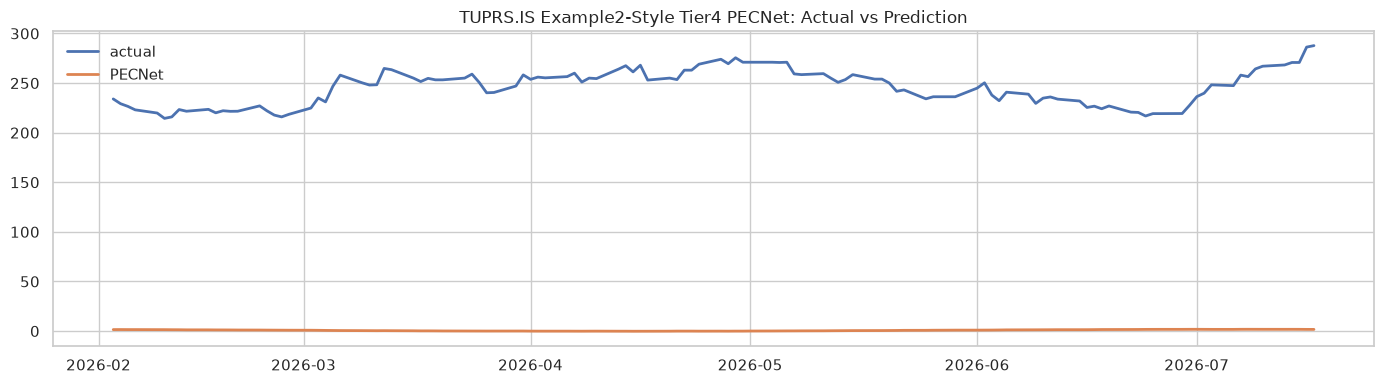

,ticker,tier,strategy,network_order,feature_index,feature_name,network_role
0,TUPRS.IS,tier4,example2_all_features_no_selection,1,0,target_history,primary_target_network
1,TUPRS.IS,tier4,example2_all_features_no_selection,2,1,prev_open,supportive_feature_network
2,TUPRS.IS,tier4,example2_all_features_no_selection,3,2,prev_high,supportive_feature_network
3,TUPRS.IS,tier4,example2_all_features_no_selection,4,3,prev_low,supportive_feature_network
4,TUPRS.IS,tier4,example2_all_features_no_selection,5,4,prev_volume,supportive_feature_network
5,TUPRS.IS,tier4,example2_all_features_no_selection,6,5,calendar_gap_days,supportive_feature_network
6,TUPRS.IS,tier4,example2_all_features_no_selection,7,6,month_sin_1,supportive_feature_network
7,TUPRS.IS,tier4,example2_all_features_no_selection,8,7,month_cos_1,supportive_feature_network
8,TUPRS.IS,tier4,example2_all_features_no_selection,9,8,month_sin_2,supportive_feature_network
9,TUPRS.IS,tier4,example2_all_features_no_selection,10,9,month_cos_2,supportive_feature_network


In [17]:
plot_predictions(predictions)
plot_variable_plan(variable_plan)


## 7.1 PECNet Utility Plot

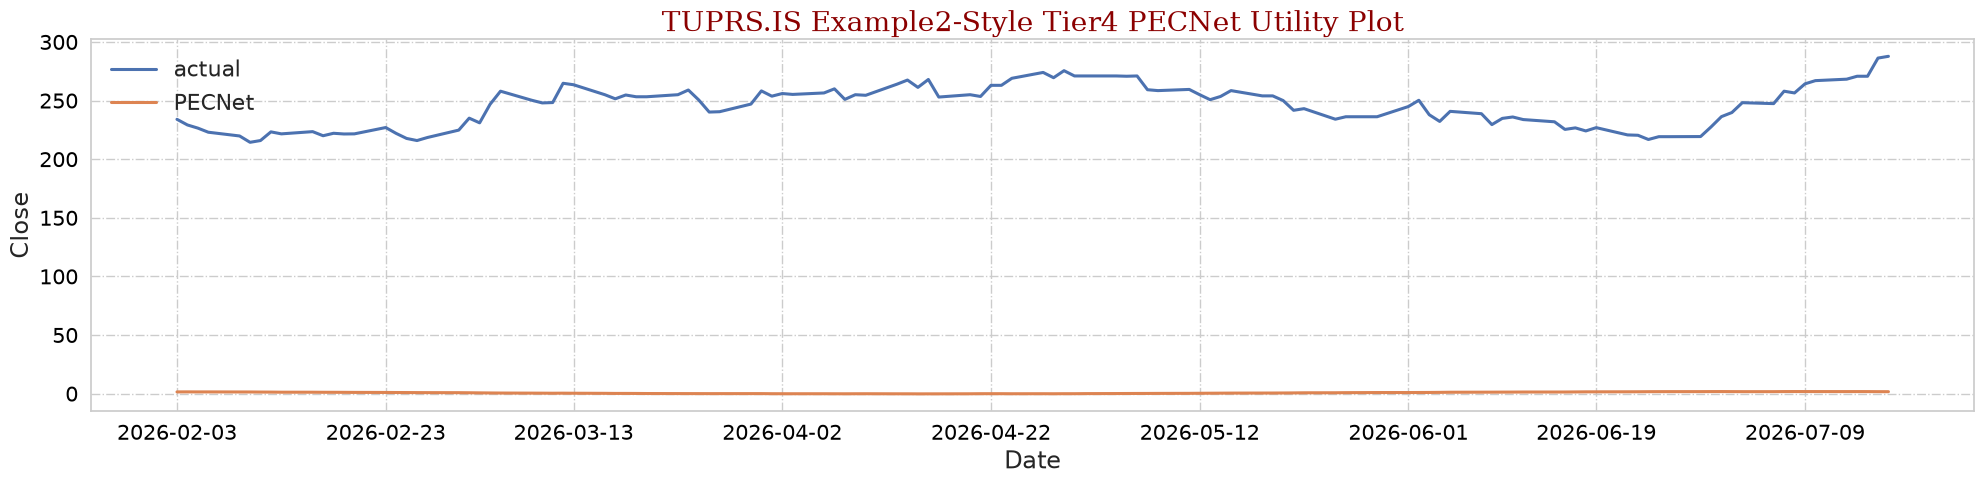

In [18]:
def plot_predictions_with_pecnet_utility(predictions: pd.DataFrame) -> None:
    for symbol, frame in predictions.groupby("unique_id", observed=True):
        frame = frame.sort_values("ds")
        Utility.plot(
            frame["ds"].to_numpy(),
            frame["y"].to_numpy(),
            frame["PECNet"].to_numpy(),
            title=f"{symbol} Example2-Style Tier4 PECNet Utility Plot",
            xlabel="Date",
            ylabel="Close",
            tick_size=8,
            labels=["actual", "PECNet"],
        )


plot_predictions_with_pecnet_utility(predictions)
